In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE





# Görselleştirmelerin notebook içinde görünmesi için
%matplotlib inline

# Veriyi yükle
df = pd.read_csv('musteri_kayip.csv')

# İlk 5 satıra göz atalım
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [33]:
# Veri setinin özet bilgisi
print("Veri Seti Şekli:", df.shape)
df.info()

# Sayısal sütunların istatistiksel özeti
df.describe()

Veri Seti Şekli: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilli

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [34]:
# Sadece boşluk karakteri içeren satırları filtreleyelim
gizli_eksik = df[df['TotalCharges'] == " "]
print(f"Sadece boşluk içeren satır sayısı: {len(gizli_eksik)}")

# Bu satırlara bir göz atalım (Genelde tenure yani abonelik süresi 0 olanlardır)
gizli_eksik[['tenure', 'MonthlyCharges', 'TotalCharges']].head()

Sadece boşluk içeren satır sayısı: 11


,tenure,MonthlyCharges,TotalCharges
488,0,52.55,
753,0,20.25,
936,0,80.85,
1082,0,25.75,
1340,0,56.05,


In [35]:
# 1. Adım: Sadece boşluk (" ") içeren satırları bulalım
bosluklar = df[df['TotalCharges'] == " "]
print(f"Sadece boşluk karakteri içeren satır sayısı: {len(bosluklar)}")

# 2. Adım: Bu boşlukları NaN (Not a Number) yap ve sütunu float'a çevir
# errors='coerce' parametresi, sayıya çevrilemeyen her şeyi (boşluk dahil) NaN yapar.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 3. Adım: Şimdi gerçekten kaç tane 'null' (boş) verimiz oldu bakalım
print("Gerçek eksik veri sayısı:", df['TotalCharges'].isnull().sum())

# 4. Adım: Bu boşlukları 0 ile dolduralım (genelde yeni müşteriler oldukları için)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Sonuç kontrol
print("Sütun tipi artık:", df['TotalCharges'].dtype)

Sadece boşluk karakteri içeren satır sayısı: 11
Gerçek eksik veri sayısı: 11
Sütun tipi artık: float64


In [36]:
# Sinsi boşlukları NaN yap ve 0 ile doldur
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

# Son bir kontrol: Eksik veri kaldı mı?
print(f"Toplam Eksik Veri: {df.isnull().sum().sum()}")
# Veri tipini doğrula
print(f"TotalCharges Tipi: {df['TotalCharges'].dtype}")

Toplam Eksik Veri: 0
TotalCharges Tipi: float64


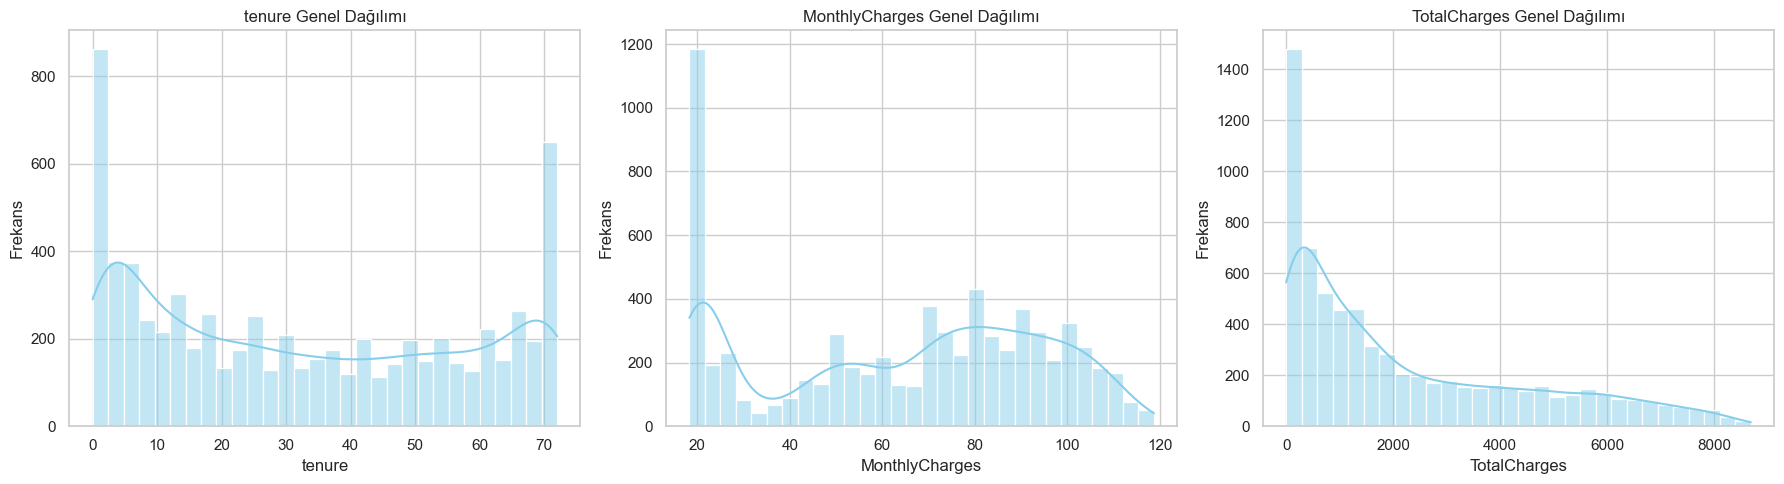

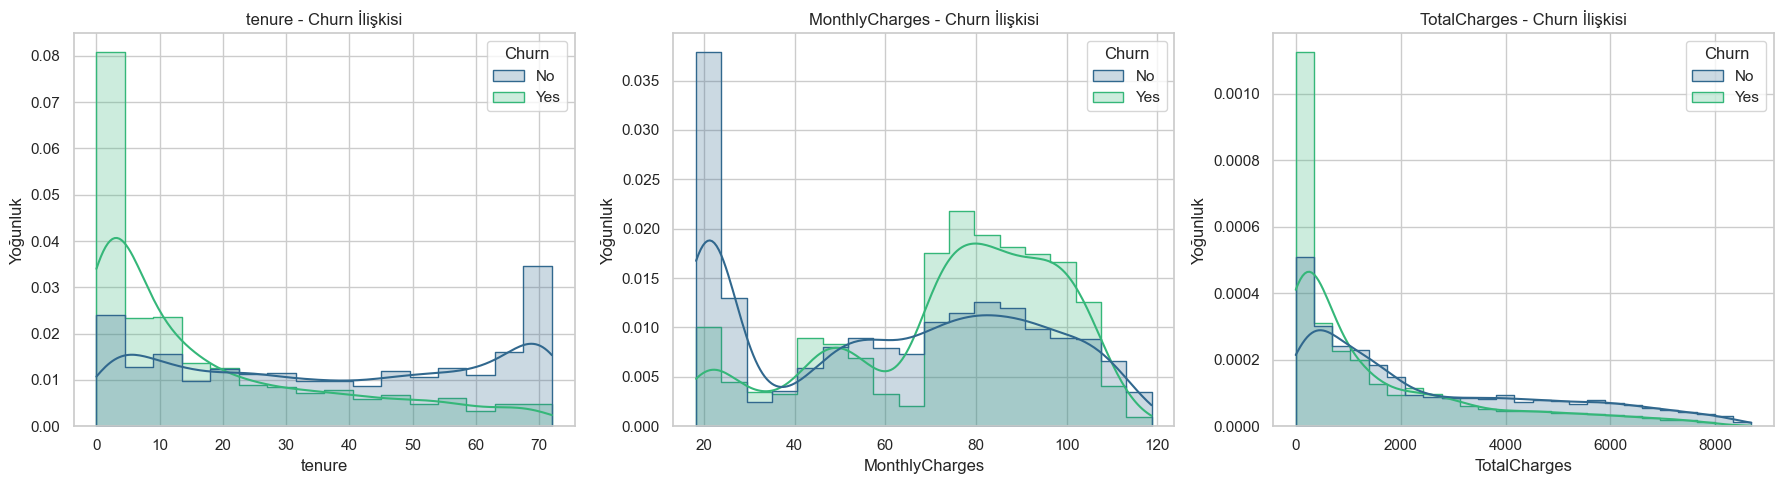

In [37]:
# Görselleştirme stilini ayarlayalım
sns.set(style="whitegrid")

# Analiz edilecek sayısal sütunlar
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# 1. TEKLİ DEĞİŞKEN ANALİZİ: Genel Dağılım (Histogram)
# Bu kısım, verinin genel yapısını (sola mı yatık, sağa mı, ortada mı toplanmış) gösterir.
plt.figure(figsize=(18, 5))

for i, col in enumerate(numeric_cols):
    plt.subplot(1, 3, i + 1)
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'{col} Genel Dağılımı')
    plt.xlabel(col)
    plt.ylabel('Frekans')

plt.tight_layout()
plt.show()

# 2. ÇOKLU DEĞİŞKEN ANALİZİ: Churn'e Göre Dağılım (Histogram + KDE)
# Bu kısım, ayrılan (Yes) ve kalan (No) müşterilerin farkını ortaya koyar.
plt.figure(figsize=(18, 5))

for i, col in enumerate(numeric_cols):
    plt.subplot(1, 3, i + 1)
    # hue='Churn' parametresi, veriyi Churn durumuna göre renklendirir
    sns.histplot(data=df, x=col, hue='Churn', kde=True, element="step", stat="density", common_norm=False, palette='viridis')
    plt.title(f'{col} - Churn İlişkisi')
    plt.xlabel(col)
    plt.ylabel('Yoğunluk')

plt.tight_layout()
plt.show()

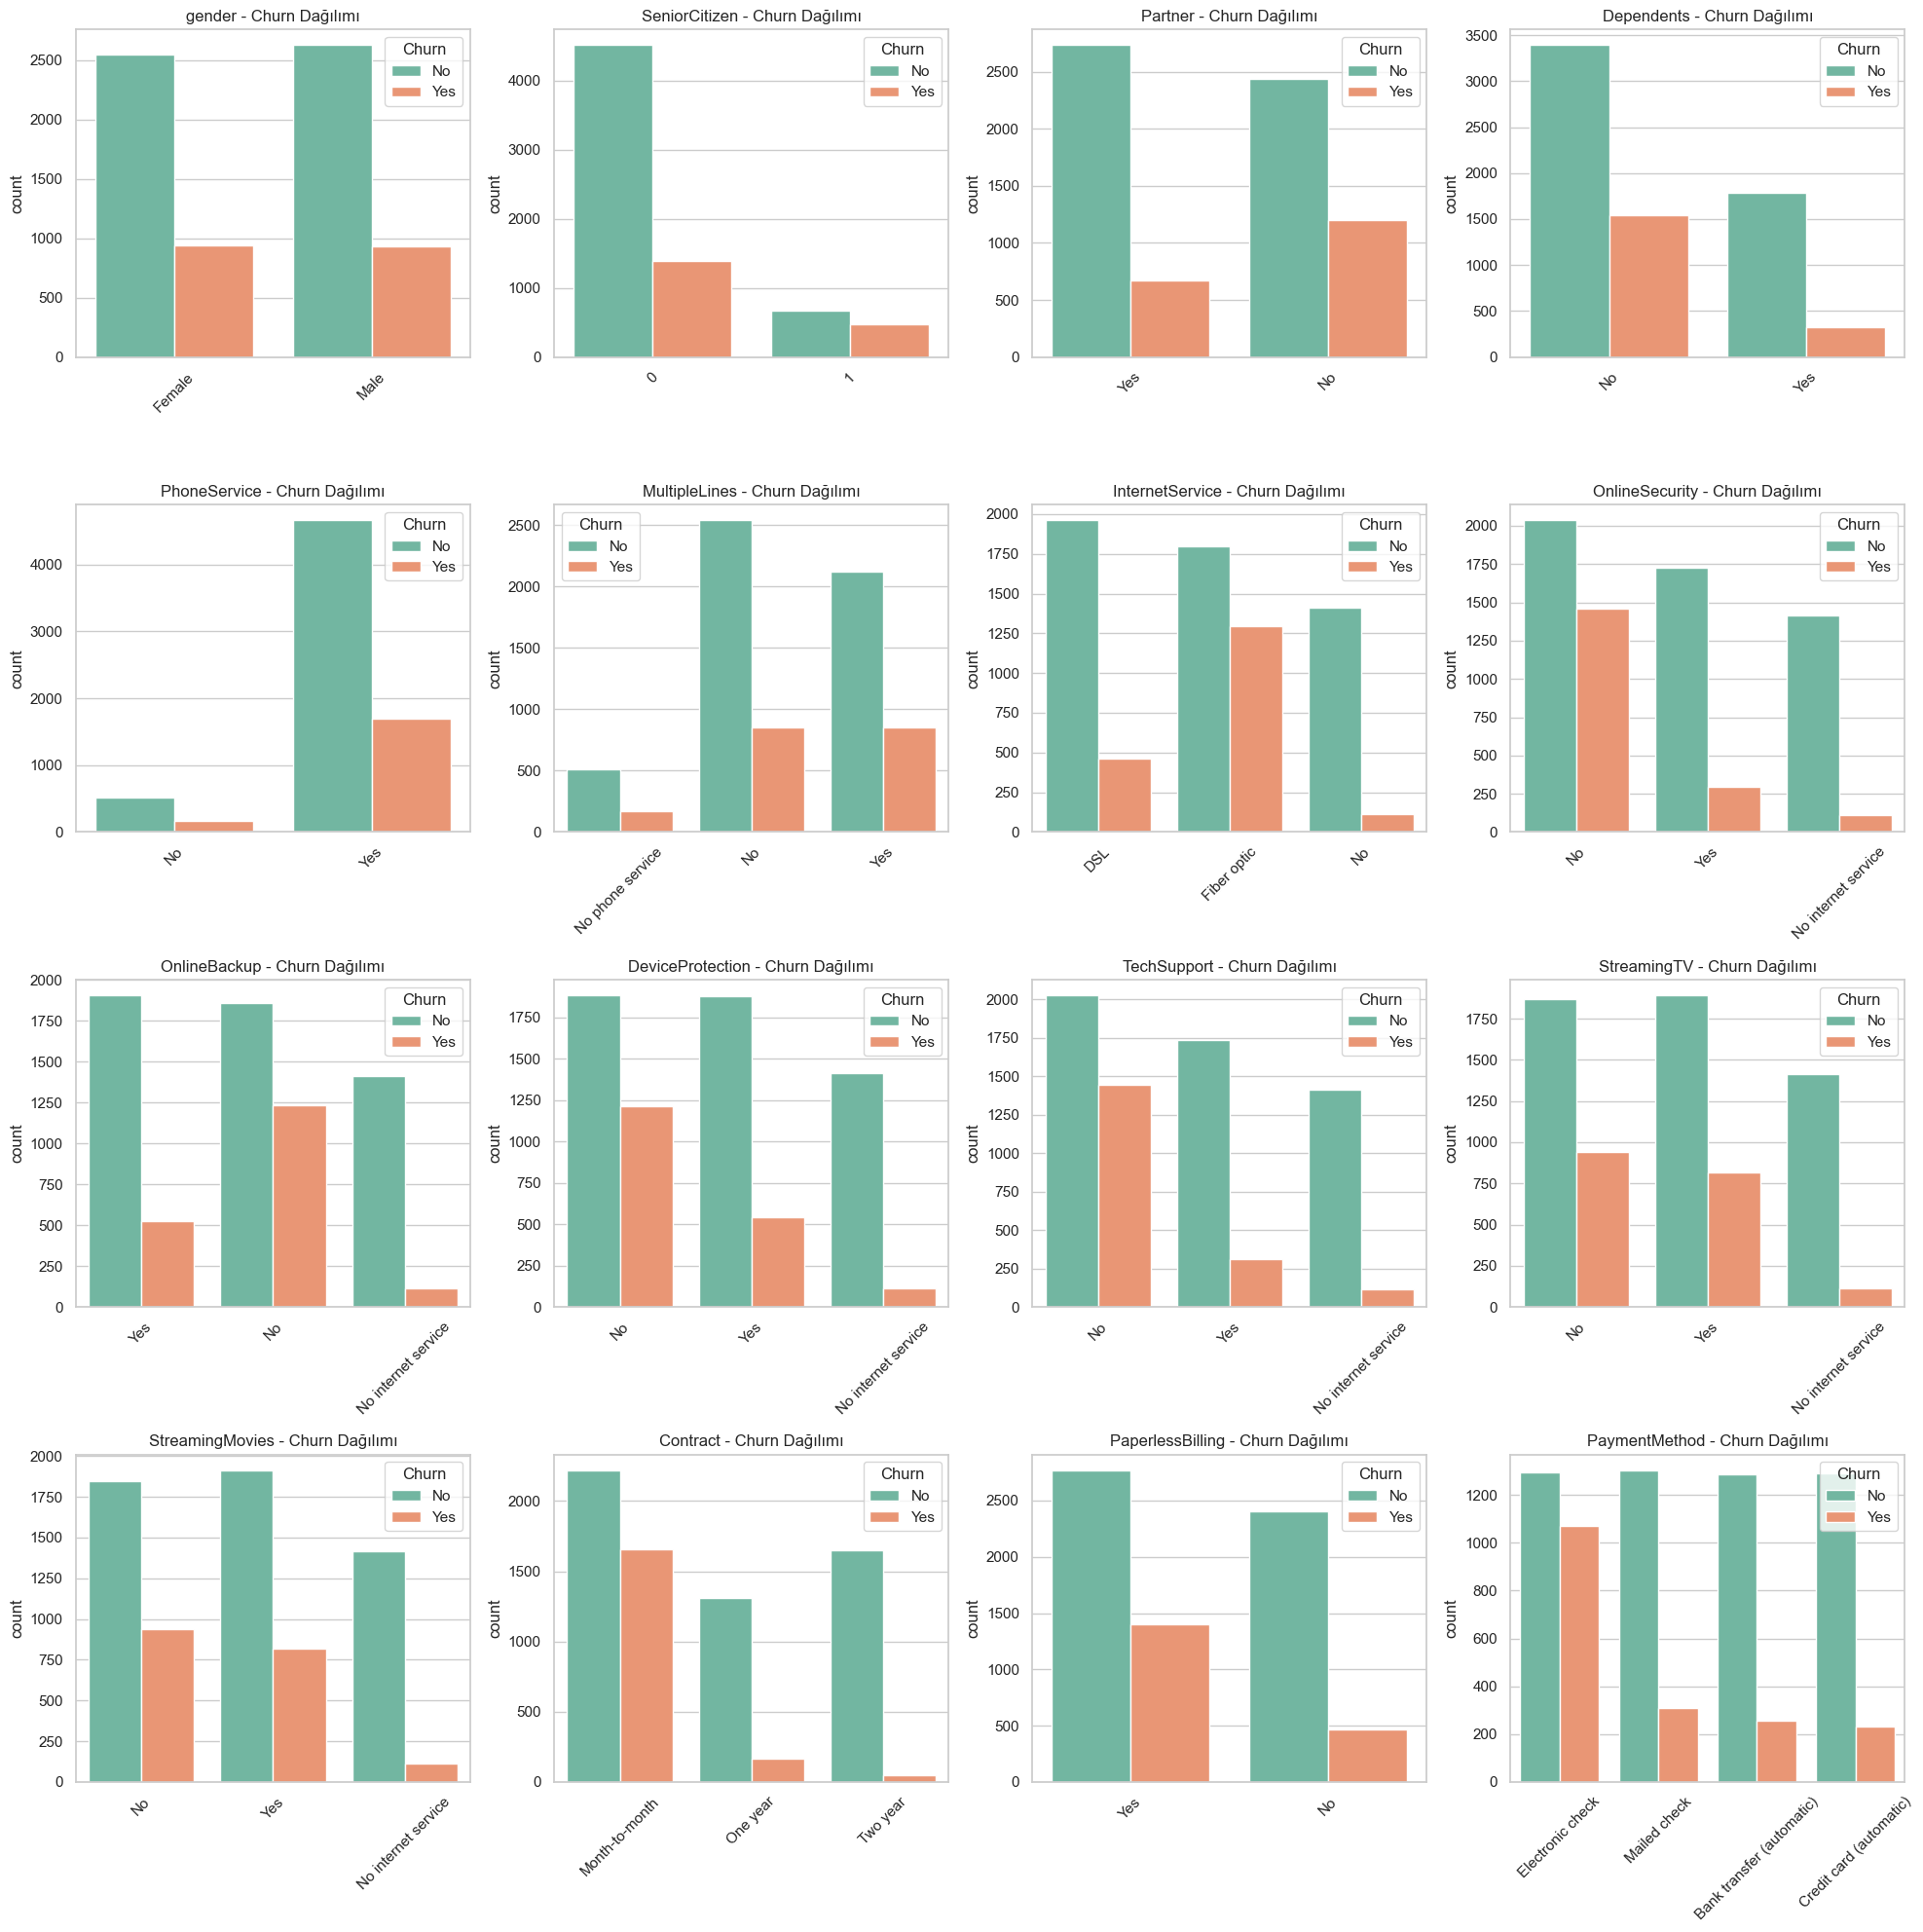

In [38]:
# Görselleştirme stilini ayarlayalım
sns.set(style="whitegrid")

# Analiz edilecek ana kategorik değişkenler
# Bu değişkenler müşterinin profilini ve satın aldığı hizmetleri gösterir
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 
            'PhoneService', 'MultipleLines', 'InternetService', 
            'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
            'TechSupport', 'StreamingTV', 'StreamingMovies', 
            'Contract', 'PaperlessBilling', 'PaymentMethod']

# Çok sayıda grafik olacağı için döngü ile çizdirmek en temiz yoldur.
# 4 satır ve 4 sütunluk bir tablo (grid) oluşturalım
fig, axes = plt.subplots(4, 4, figsize=(20, 20))
axes = axes.flatten() # Eksenleri tek boyutlu listeye çevirir (döngü kolaylığı için)

for i, col in enumerate(cat_cols):
    # hue='Churn' parametresi ile ayrılan ve kalanları renklerle ayırıyoruz
    sns.countplot(x=col, hue='Churn', data=df, ax=axes[i], palette='Set2')
    
    # Başlık ve eksen ayarları
    axes[i].set_title(f'{col} - Churn Dağılımı')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45) # Yazıların üst üste binmemesi için eğik yaz

# Düzenin sıkışık olmaması için
plt.tight_layout()
plt.show()

In [44]:
multi_cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                  'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                  'Contract', 'PaymentMethod', 'tenure_segment']

In [47]:
df['tenure_segment'] = df['tenure_segment'].astype(str)

In [46]:
# ─────────────────────────────────────────────
# 1.5 ÖZELLİK MÜHENDİSLİĞİ
# ─────────────────────────────────────────────

df['tenure_segment'] = pd.cut(
    df['tenure'],
    bins=[0, 6, 12, 24, 48, 72],
    labels=['0-6ay', '6-12ay', '1-2yil', '2-4yil', '4yil+'],
    include_lowest=True
).astype(str)

df['ucret_per_tenure'] = df['MonthlyCharges'] / (df['tenure'] + 1)

df['harcama_farki'] = df['TotalCharges'] - (df['MonthlyCharges'] * df['tenure'])

hizmet_kolonlari = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                    'TechSupport', 'StreamingTV', 'StreamingMovies']
df['hizmet_sayisi'] = df[hizmet_kolonlari].apply(
    lambda x: x.str.contains('Yes', na=False).sum(), axis=1
)

df['ucret_per_hizmet'] = df['MonthlyCharges'] / (df['hizmet_sayisi'] + 1)

df['risk_kombinasyon'] = (
    (df['Contract'] == 'Month-to-month') &
    (df['MonthlyCharges'] > df['MonthlyCharges'].median())
).astype(int)

In [48]:
from sklearn.preprocessing import MinMaxScaler, LabelEncoder 

# 1. VERİYİ YÜKLEME VE TEMİZLEME (Hata almamak için baştan alıyoruz)
df = pd.read_csv('musteri_kayip.csv')

# TotalCharges temizliği
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

# customerID gereksiz
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

# 2. ENCODING (KATEGORİK -> SAYISAL)

# A) Binary (İki seçenekli) Değişkenler için Label Encoding
le = LabelEncoder()
binary_cols = [col for col in df.columns if df[col].dtype == 'object' and df[col].nunique() == 2]

print("Label Encoding Yapılan Sütunlar:\n", binary_cols)

for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# B) Multi-Class (Çok seçenekli) Değişkenler için One-Hot Encoding
# drop_first=True diyerek gereksiz kolon tekrarından kaçınıyoruz
df = pd.get_dummies(df, drop_first=True)

# 3. SCALING (ÖLÇEKLENDİRME)
# Verilerimiz normal dağılmadığı için MinMaxScaler kullanıyoruz
scaler = MinMaxScaler()
cols_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']

df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])


# SONUÇLARI GÖRELİM
print("\n--- İşlenmiş Veri Seti Boyutu ---")
print(df.shape)
print("\n--- İlk 5 Satır ---")
print(df.head())

Label Encoding Yapılan Sütunlar:
 ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

--- İşlenmiş Veri Seti Boyutu ---
(7043, 31)

--- İlk 5 Satır ---
   gender  SeniorCitizen  Partner  Dependents    tenure  PhoneService  \
0       0              0        1           0  0.013889             0   
1       1              0        0           0  0.472222             1   
2       1              0        0           0  0.027778             1   
3       1              0        0           0  0.625000             0   
4       0              0        0           0  0.027778             1   

   PaperlessBilling  MonthlyCharges  TotalCharges  Churn  ...  \
0                 1        0.115423      0.003437      0  ...   
1                 0        0.385075      0.217564      0  ...   
2                 1        0.354229      0.012453      1  ...   
3                 0        0.239303      0.211951      0  ...   
4                 1        0.521891      0.017462     

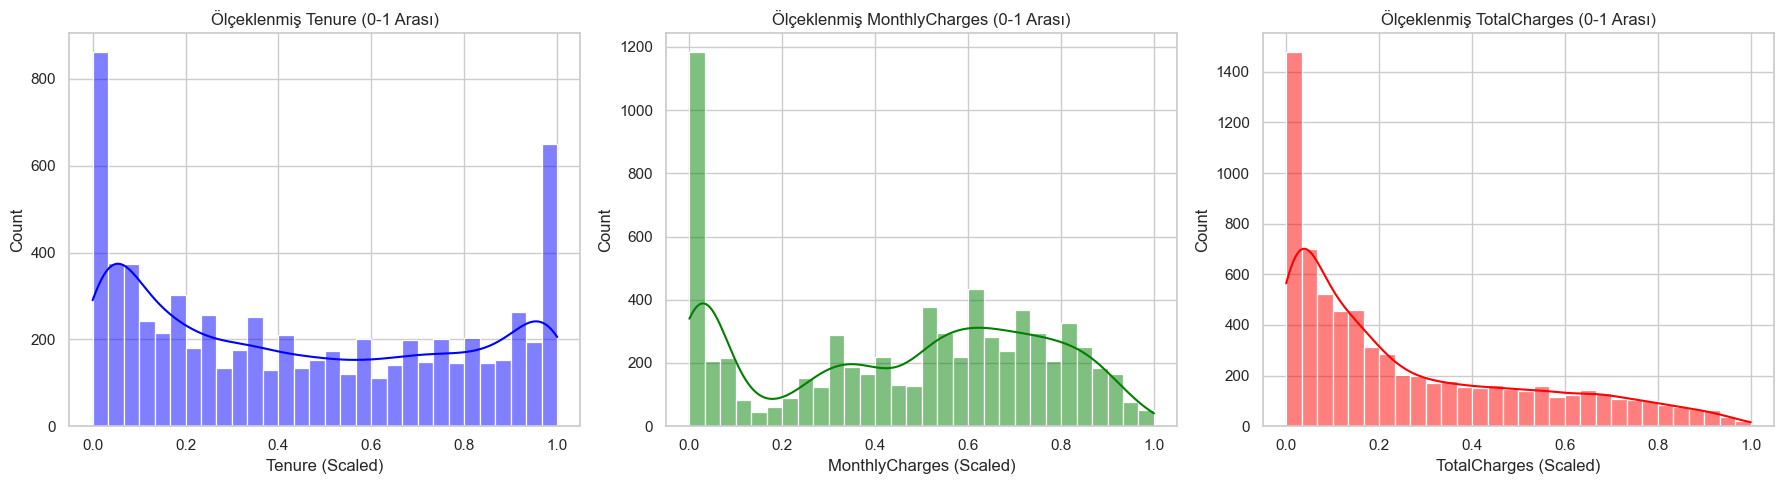

In [ ]:
# Daha önce oluşturduğumuz ölçeklenmiş 'df' veri setini kullanıyoruz.
# (Eğer df kaybolduysa yukarıdaki kod bloğunu tekrar çalıştırmalısın)

plt.figure(figsize=(18, 5))

# 1. Ölçeklenmiş Tenure (Abonelik Süresi)
plt.subplot(1, 3, 1)
sns.histplot(df['tenure'], kde=True, color='blue', bins=30)
plt.title('Ölçeklenmiş Tenure (0-1 Arası)')
plt.xlabel('Tenure (Scaled)')

# 2. Ölçeklenmiş MonthlyCharges (Aylık Ücret)
plt.subplot(1, 3, 2)
sns.histplot(df['MonthlyCharges'], kde=True, color='green', bins=30)
plt.title('Ölçeklenmiş MonthlyCharges (0-1 Arası)')
plt.xlabel('MonthlyCharges (Scaled)')

# 3. Ölçeklenmiş TotalCharges (Toplam Ücret)
plt.subplot(1, 3, 3)
sns.histplot(df['TotalCharges'], kde=True, color='red', bins=30)
plt.title('Ölçeklenmiş TotalCharges (0-1 Arası)')
plt.xlabel('TotalCharges (Scaled)')

plt.tight_layout()
plt.show()

--- CHURN İLE EN YÜKSEK POZİTİF İLİŞKİSİ OLANLAR (Müşteri Kaybettirenler) ---
Churn                             1.000000
InternetService_Fiber optic       0.308020
PaymentMethod_Electronic check    0.301919
MonthlyCharges                    0.193356
PaperlessBilling                  0.191825
SeniorCitizen                     0.150889
Name: Churn, dtype: float64

--- CHURN İLE EN YÜKSEK NEGATİF İLİŞKİSİ OLANLAR (Müşteri Tutanlar) ---
TechSupport_No internet service       -0.227890
StreamingTV_No internet service       -0.227890
StreamingMovies_No internet service   -0.227890
Contract_Two year                     -0.302253
tenure                                -0.352229
Name: Churn, dtype: float64


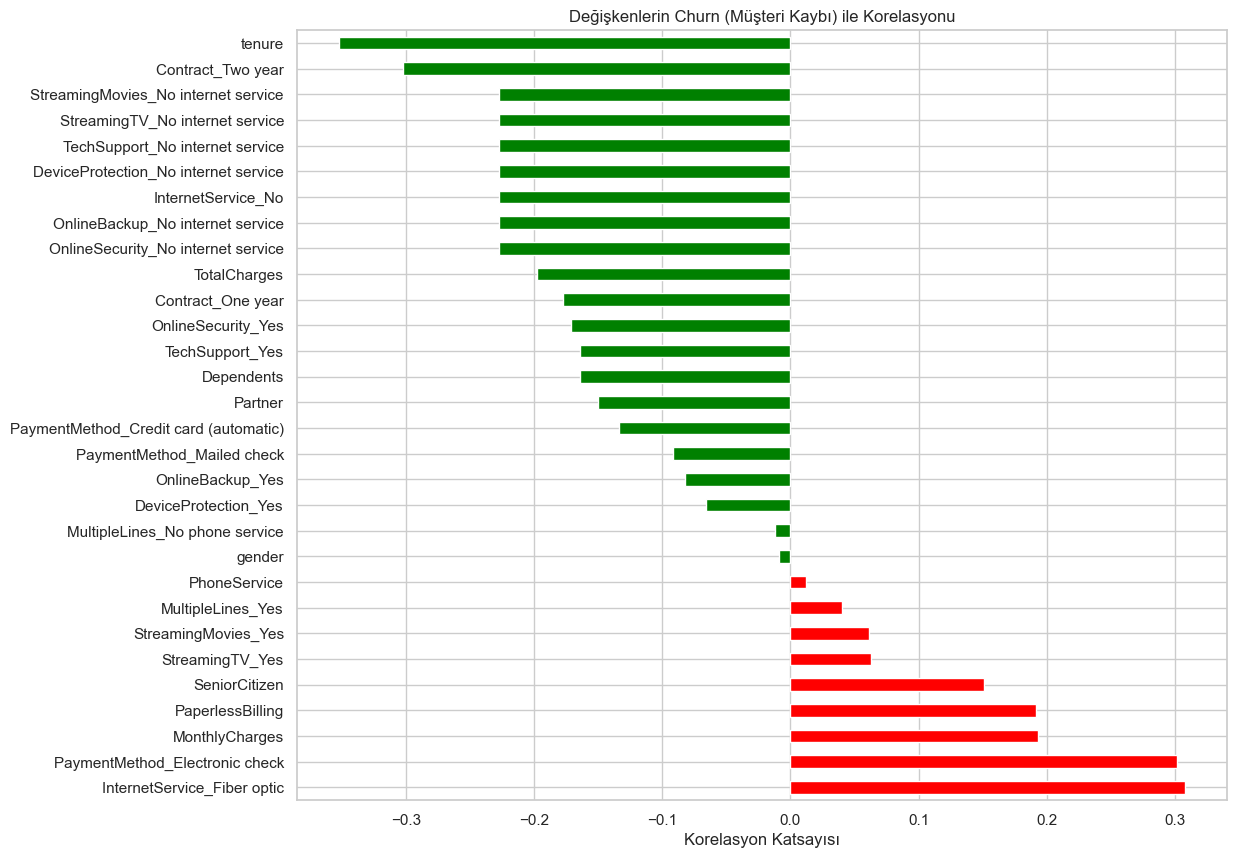

In [ ]:
# Encoding (Label Encoding - Binary)
le = LabelEncoder()
binary_cols = [col for col in df.columns if df[col].dtype == 'object' and df[col].nunique() == 2]
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# Encoding (One-Hot Encoding - Multi-class)
df = pd.get_dummies(df, drop_first=True)

# Scaling (İsteğe bağlı ama model için gerekli, korelasyonu etkilemez ama hazır olsun)
scaler = MinMaxScaler()
cols_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

# 2. KORELASYON ANALİZİ
# Hedef değişkenimiz 'Churn' ile diğer tüm değişkenlerin ilişkisi
correlation = df.corr()['Churn'].sort_values(ascending=False)

# İlk 5 (En çok kaybettirenler) ve Son 5 (En çok tutanlar)
print("--- CHURN İLE EN YÜKSEK POZİTİF İLİŞKİSİ OLANLAR (Müşteri Kaybettirenler) ---")
print(correlation.head(6)) # İlk sırada Churn'ün kendisi olacağı için 6 aldık

print("\n--- CHURN İLE EN YÜKSEK NEGATİF İLİŞKİSİ OLANLAR (Müşteri Tutanlar) ---")
print(correlation.tail(5))

# 3. GÖRSELLEŞTİRME (Bar Plot)
plt.figure(figsize=(12, 10))
# Churn'ün kendisini grafikten çıkarıyoruz (korelasyonu 1.0 olduğu için)
correlation.drop('Churn').plot(kind='barh', color=correlation.drop('Churn').apply(lambda x: 'red' if x > 0 else 'green'))
plt.title('Değişkenlerin Churn (Müşteri Kaybı) ile Korelasyonu')
plt.xlabel('Korelasyon Katsayısı')
plt.show()

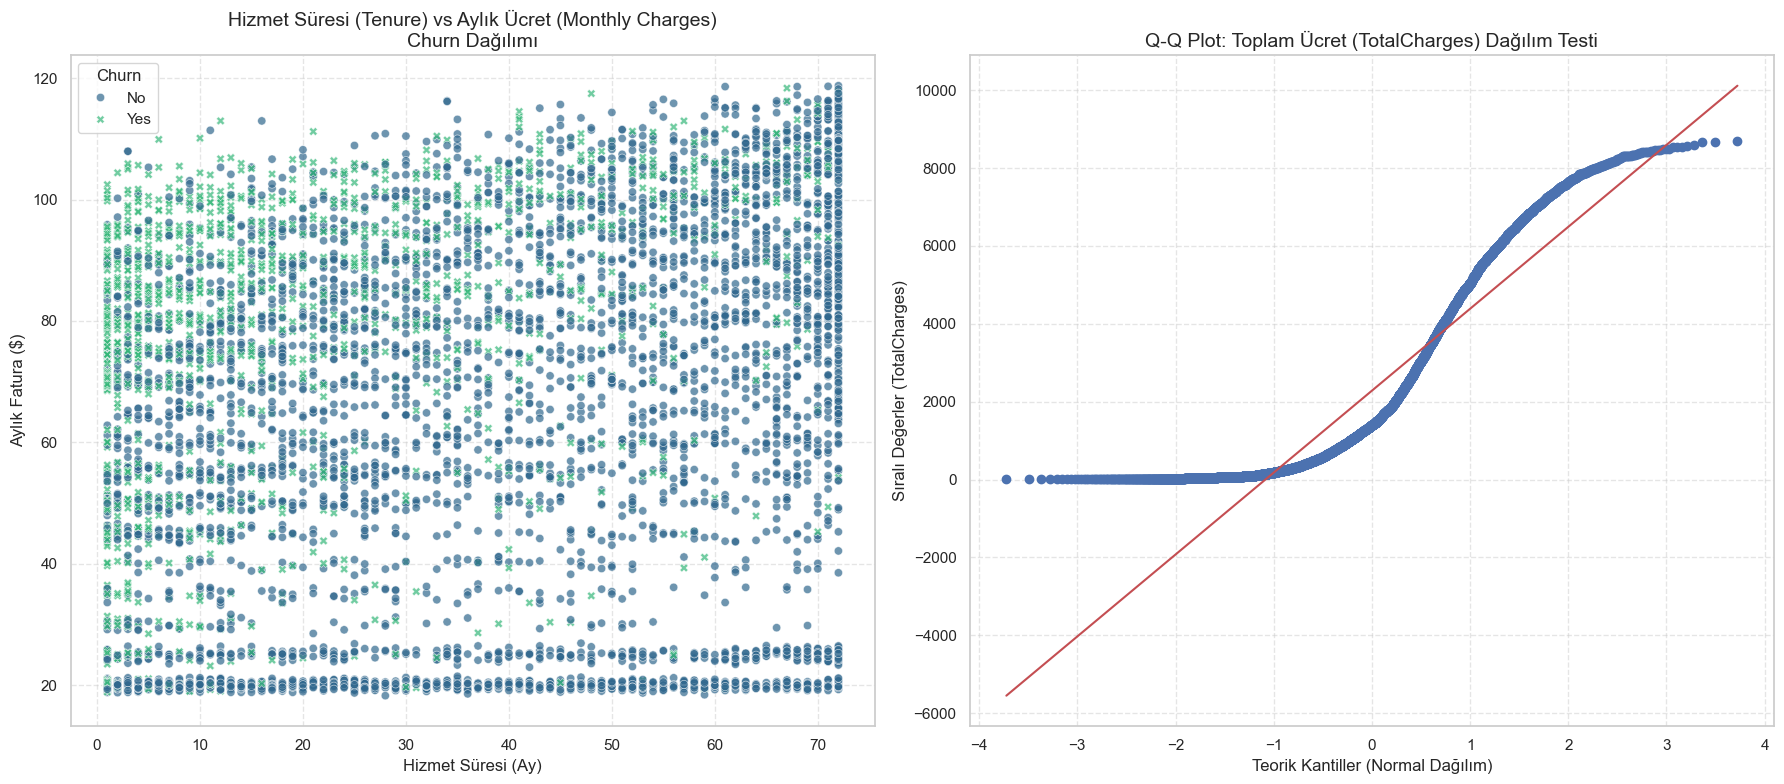

In [ ]:
# Veri setini yükleme
df = pd.read_csv('musteri_kayip.csv')

# 'TotalCharges' sütunundaki boşlukları temizleyip sayısal veriye çevirme
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True) # Eksik verileri temizleme

# Grafik ayarları
plt.figure(figsize=(18, 8))

# --- 1. SCATTER PLOT (Saçılım Grafiği) ---
# Amaç: Hizmet süresi ve Fatura tutarı arasındaki ilişkinin Churn üzerindeki etkisini görmek.
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='tenure', y='MonthlyCharges', hue='Churn', style='Churn', palette='viridis', alpha=0.7)
plt.title('Hizmet Süresi (Tenure) vs Aylık Ücret (Monthly Charges)\nChurn Dağılımı', fontsize=14)
plt.xlabel('Hizmet Süresi (Ay)', fontsize=12)
plt.ylabel('Aylık Fatura ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# --- 2. QUANTILE PLOT (Q-Q Plot) ---
# Amaç: TotalCharges değişkeninin normal dağılıma uygunluğunu test etmek.
plt.subplot(1, 2, 2)
stats.probplot(df['TotalCharges'], dist="norm", plot=plt)
plt.title('Q-Q Plot: Toplam Ücret (TotalCharges) Dağılım Testi', fontsize=14)
plt.xlabel('Teorik Kantiller (Normal Dağılım)', fontsize=12)
plt.ylabel('Sıralı Değerler (TotalCharges)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
# 2. TotalCharges sütunundaki boşlukları (string) 0 ile doldurup sayısal tipe çevirme
# (Veri setinde 11 satırda boşluk karakteri mevcuttu)
df['TotalCharges'] = df['TotalCharges'].replace(' ', '0')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

# 3. Label Encoding (Sadece 2 kategorisi olan değişkenler için)
# Bu işlem Yes/No veya Male/Female gibi ikili değerleri 0 ve 1 yapar.
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
le = LabelEncoder()

for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# 4. One-Hot Encoding (3 veya daha fazla kategorisi olan değişkenler için)
# Bu işlem her kategoriyi yeni bir sütun yapar (Kukla Değişkenler).
multi_cat_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
    'Contract', 'PaymentMethod'
]

# drop_first=True: İlk kategoriyi atarak 'kukla değişken tuzağını' önler ve modelin daha verimli çalışmasını sağlar.
df_final = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)

# 5. Model için anlamsız olan customerID sütununu kaldırma
df_final = df_final.drop('customerID', axis=1)

# Sonucu inceleme
print(f"İşlem sonrası veri seti boyutu: {df_final.shape}")
print(df_final.head())

İşlem sonrası veri seti boyutu: (7032, 31)
   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   
3       1              0        0           0      45             0   
4       0              0        0           0       2             1   

   PaperlessBilling  MonthlyCharges  TotalCharges  Churn  ...  \
0                 1           29.85         29.85      0  ...   
1                 0           56.95       1889.50      0  ...   
2                 1           53.85        108.15      1  ...   
3                 0           42.30       1840.75      0  ...   
4                 1           70.70        151.65      1  ...   

   TechSupport_Yes  StreamingTV_No internet service  StreamingTV_Yes  \
0                0                                0                

In [ ]:
# 1. Özellikleri (X) ve Hedef Değişkeni (y) Ayırma
# 'Churn' bizim tahmin etmek istediğimiz değer, diğerleri girdilerimizdir.
X = df_final.drop('Churn', axis=1)
y = df_final['Churn']

# 2. Train-Test Split (Veriyi Bölme)
# Verinin %80'ini eğitim, %20'sini test için ayırıyoruz. 
# random_state=42, sonuçların her çalıştırdığınızda aynı çıkmasını sağlar.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 3. Feature Scaling (Ölçeklendirme)
# Bazı sütunlar (MonthlyCharges, TotalCharges, tenure) çok yüksek değerlere sahipken,
# encoding yaptığımız sütunlar sadece 0 ve 1'den oluşuyor.
# StandardScaler, sayısal değerleri ortalaması 0, standart sapması 1 olacak şekilde dönüştürür.

scaler = StandardScaler()

# Sadece sayısal (sürekli) sütunları ölçeklendirmek daha sağlıklıdır 
# Ancak tüm X setine uygulamak da modellerin çoğunda sorun yaratmaz.
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Eğitim seti boyutu:", X_train.shape)
print("Test seti boyutu:", X_test.shape)

Eğitim seti boyutu: (5625, 30)
Test seti boyutu: (1407, 30)


In [ ]:


# 1. Veriyi Ayırma (X: Özellikler, y: Hedef)
X = df_final.drop('Churn', axis=1)
y = df_final['Churn']

# 2. Train-Test Split (Veriyi Bölme)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 3. Feature Scaling (Ölçeklendirme)
# Burada X_train_scaled ve X_test_scaled değişkenlerini tanımlıyoruz
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Decision Tree Modelini Tanımlama ve Eğitme
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

# 5. Tahmin Yapma
y_pred_dt = dt_model.predict(X_test_scaled)

# 6. Sonuçları Görüntüleme
print(f"Decision Tree Doğruluğu: {accuracy_score(y_test, y_pred_dt):.4f}")
print("\nKarmaşıklık Matrisi:")
print(confusion_matrix(y_test, y_pred_dt))
print("\nSınıflandırma Raporu:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Doğruluğu: 0.7264

Karmaşıklık Matrisi:
[[830 203]
 [182 192]]

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.82      0.80      0.81      1033
           1       0.49      0.51      0.50       374

    accuracy                           0.73      1407
   macro avg       0.65      0.66      0.66      1407
weighted avg       0.73      0.73      0.73      1407



In [ ]:
from sklearn.tree import DecisionTreeClassifier

# class_weight='balanced' eklemek yeterlidir
model_balanced = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
model_balanced.fit(X_train_scaled, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)

In [ ]:
# Tahmin yap
y_pred_balanced = model_balanced.predict(X_test_scaled)

# Sonuçları görüntüle
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred_balanced))
print(confusion_matrix(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.92      0.63      0.75      1033
           1       0.45      0.84      0.59       374

    accuracy                           0.69      1407
   macro avg       0.69      0.74      0.67      1407
weighted avg       0.79      0.69      0.71      1407

[[654 379]
 [ 59 315]]


In [ ]:
# 1. SMOTE Uygulaması (Sadece Eğitim Setine!)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# SMOTE öncesi ve sonrası dağılımı görelim:
print("SMOTE Öncesi Eğitim Seti Dağılımı:")
print(y_train.value_counts())
print("\nSMOTE Sonrası Eğitim Seti Dağılımı:")
print(y_train_smote.value_counts())
print("-" * 40)

# 2. Modeli Eğitme (Artık scale_pos_weight kullanmıyoruz çünkü veri dengelendi!)
# Basit bir XGBoost modeli kuruyoruz
smote_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

# Modeli SMOTE ile eşitlenmiş veride eğitiyoruz
smote_model.fit(X_train_smote, y_train_smote)

# 3. Tahmin (Orijinal, dokunulmamış test verisi üzerinde!)
y_pred_smote = smote_model.predict(X_test_scaled)

# 4. Sonuçlar
print("\n--- SMOTE Destekli Sınıflandırma Raporu ---")
print(classification_report(y_test, y_pred_smote))

print("\n--- Karmaşıklık Matrisi ---")
print(confusion_matrix(y_test, y_pred_smote))

SMOTE Öncesi Eğitim Seti Dağılımı:
0    4130
1    1495
Name: Churn, dtype: int64

SMOTE Sonrası Eğitim Seti Dağılımı:
1    4130
0    4130
Name: Churn, dtype: int64
----------------------------------------


c:\Users\oguzz\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(



--- SMOTE Destekli Sınıflandırma Raporu ---
              precision    recall  f1-score   support

           0       0.87      0.83      0.85      1033
           1       0.57      0.64      0.61       374

    accuracy                           0.78      1407
   macro avg       0.72      0.74      0.73      1407
weighted avg       0.79      0.78      0.78      1407


--- Karmaşıklık Matrisi ---
[[854 179]
 [133 241]]


In [ ]:
# 1. Sınıf dengesizliğini çözmek için oran hesaplama
# (Notebook'taki y_train değişkeni kullanılıyor)
negative_class_count = (y_train == 0).sum()
positive_class_count = (y_train == 1).sum()
scale_weight = negative_class_count / positive_class_count

# 2. XGBoost Modelini Tanımlama
xgb_model = xgb.XGBClassifier(
    scale_pos_weight=scale_weight,
    n_estimators=100,         
    max_depth=5,              
    learning_rate=0.1,        
    random_state=42,
    eval_metric='logloss'     
)

# 3. Modeli Eğitme 
# (Notebook'taki doğru değişken olan X_train_scaled kullanılıyor)
xgb_model.fit(X_train_scaled, y_train)

# 4. Test Seti Üzerinde Tahmin Yapma
# (Notebook'taki doğru değişken olan X_test_scaled kullanılıyor)
y_pred_xgb = xgb_model.predict(X_test_scaled)

# 5. Sonuçları Görüntüleme
print("--- XGBoost Sınıflandırma Raporu ---")
print(classification_report(y_test, y_pred_xgb))

print("\n--- Karmaşıklık Matrisi (Confusion Matrix) ---")
print(confusion_matrix(y_test, y_pred_xgb))

--- XGBoost Sınıflandırma Raporu ---
              precision    recall  f1-score   support

           0       0.89      0.72      0.80      1033
           1       0.50      0.76      0.60       374

    accuracy                           0.73      1407
   macro avg       0.69      0.74      0.70      1407
weighted avg       0.79      0.73      0.74      1407


--- Karmaşıklık Matrisi (Confusion Matrix) ---
[[742 291]
 [ 88 286]]


In [ ]:
# 1. Modelin direkt 1/0 tahmini yerine, olasılık değerlerini (0.0 ile 1.0 arası) alalım
y_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1] # Sadece 1 (Churn) olma olasılıkları

# 2. Yeni bir Karar Eşiği (Threshold) belirleyelim (Örn: %65 emin olmadan 1 deme)
yeni_esik_degeri = 0.65

# 3. Olasılık bu eşikten büyükse 1, değilse 0 yap
y_pred_high_precision = (y_pred_proba >= yeni_esik_degeri).astype(int)

# 4. Yeni Sonuçları Görelim
print(f"--- Eşik Değeri {yeni_esik_degeri} Olarak Ayarlandığında Sonuçlar ---")
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred_high_precision))
print("\nKarmaşıklık Matrisi:")
print(confusion_matrix(y_test, y_pred_high_precision))

--- Eşik Değeri 0.65 Olarak Ayarlandığında Sonuçlar ---
              precision    recall  f1-score   support

           0       0.86      0.84      0.85      1033
           1       0.59      0.63      0.61       374

    accuracy                           0.78      1407
   macro avg       0.72      0.74      0.73      1407
weighted avg       0.79      0.78      0.79      1407


Karmaşıklık Matrisi:
[[867 166]
 [138 236]]


In [ ]:
# 1. VERİYİ YÜKLE VE TEMİZLE
df = pd.read_csv('musteri_kayip.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)

# 2. ENCODING (Kategorik verileri sayısallaştırma)
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

multi_cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
                  'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
                  'Contract', 'PaymentMethod']
df_final = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)

# 3. VERİYİ AYIRMA
X = df_final.drop('Churn', axis=1)
y = df_final['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 4. ÖLÇEKLENDİRME
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. CATBOOST MODELİNİ KURMA
# CatBoost'un gücü: auto_class_weights='Balanced' ile dengesizliği otomatik çözer.
cat_model = CatBoostClassifier(
    iterations=200,                # Ağaç sayısı (CatBoost çok hızlıdır, 200 idealdir)
    learning_rate=0.05,            # Öğrenme hızı (daha sindirerek öğrenmesi için biraz düşürdük)
    depth=6,                       # Ağaç derinliği
    auto_class_weights='Balanced', # Dengesiz veriyi otomatik dengeler!
    verbose=0,                     # Çalışırken ekrana yüzlerce satır log basmasını engeller
    random_state=42
)

# 6. EĞİTİM VE TAHMİN
cat_model.fit(X_train_scaled, y_train)
y_pred_cat = cat_model.predict(X_test_scaled)

# 7. SONUÇLARI YAZDIR
print("--- CatBoost Sınıflandırma Raporu ---")
print(classification_report(y_test, y_pred_cat))

print("\n--- Karmaşıklık Matrisi (Confusion Matrix) ---")
print(confusion_matrix(y_test, y_pred_cat))

--- CatBoost Sınıflandırma Raporu ---
              precision    recall  f1-score   support

           0       0.92      0.75      0.82      1036
           1       0.54      0.83      0.65       373

    accuracy                           0.77      1409
   macro avg       0.73      0.79      0.74      1409
weighted avg       0.82      0.77      0.78      1409


--- Karmaşıklık Matrisi (Confusion Matrix) ---
[[772 264]
 [ 65 308]]


✅ Optimal eşik  : 0.205
💰 Minimum maliyet: 33,150 TL

--- Optimal Eşikli Sınıflandırma Raporu ---
              precision    recall  f1-score   support

           0       0.98      0.47      0.63      1036
           1       0.40      0.97      0.56       373

    accuracy                           0.60      1409
   macro avg       0.69      0.72      0.60      1409
weighted avg       0.82      0.60      0.61      1409


--- Optimal Eşikli Confusion Matrix ---
[[483 553]
 [ 11 362]]

--- Müşteri Segment Dağılımı ---
               musteri_sayisi  ort_kayip_olasiligi  gercek_kayip_sayisi
segment                                                                
🟢 Güvenli                 620                0.103                   28
🟡 Riskli                  335                0.450                   75
🔴 Yüksek Risk             454                0.779                  270

╔══════════════╦═══════════════════════════════════════════╦══════════════════════╗
║ Segment      ║ Aksiyon        

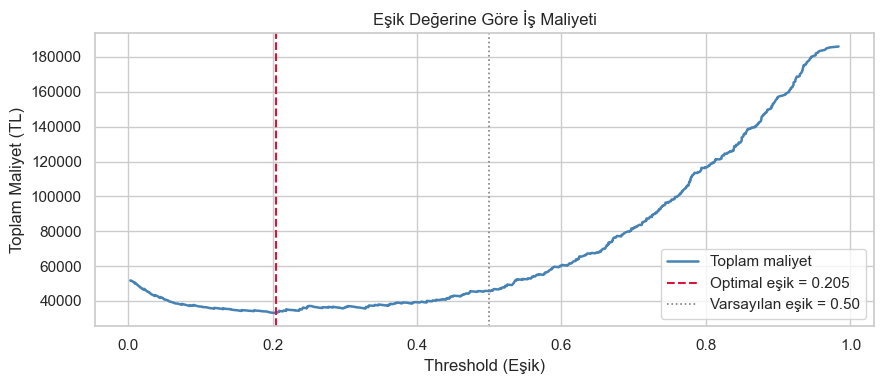

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, classification_report, confusion_matrix

# ─────────────────────────────────────────────
# 8. THRESHOLD OPTİMİZASYONU
# ─────────────────────────────────────────────

# Olasılıkları al (sadece pozitif sınıf = kayacak)
y_proba = cat_model.predict_proba(X_test_scaled)[:, 1]

# ── İŞ MALİYETLERİNİ TANIMLA ──────────────────
# Bu iki sayıyı kendi şirketine göre değiştir!
PROMOSYON_MALIYETI = 50     # TL — 1 FP'nin maliyeti (gereksiz promosyon)
MUSTERI_LTV_KAYBI  = 500    # TL — 1 FN'nin maliyeti (kaçırılan müşteri)
# ───────────────────────────────────────────────

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# Her eşik için toplam iş maliyetini hesapla
costs = []
for thresh in thresholds:
    y_pred_temp = (y_proba >= thresh).astype(int)
    fp = ((y_pred_temp == 1) & (y_test == 0)).sum()
    fn = ((y_pred_temp == 0) & (y_test == 1)).sum()
    costs.append(fp * PROMOSYON_MALIYETI + fn * MUSTERI_LTV_KAYBI)

optimal_idx       = int(np.argmin(costs))
optimal_threshold = thresholds[optimal_idx]
print(f"✅ Optimal eşik  : {optimal_threshold:.3f}")
print(f"💰 Minimum maliyet: {min(costs):,} TL")

# ─────────────────────────────────────────────
# 9. OPTİMAL EŞİKLE YENİDEN TAHMİN
# ─────────────────────────────────────────────

y_pred_optimal = (y_proba >= optimal_threshold).astype(int)

print("\n--- Optimal Eşikli Sınıflandırma Raporu ---")
print(classification_report(y_test, y_pred_optimal))

print("\n--- Optimal Eşikli Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred_optimal))

# ─────────────────────────────────────────────
# 10. MÜŞTERİ SEGMENTASYONU
# ─────────────────────────────────────────────

# Test setini bir DataFrame'e dönüştür
df_result = X_test.copy()
df_result['kayip_olasiligi'] = y_proba
df_result['gercek_durum']    = y_test.values

# Üç segmente ayır
df_result['segment'] = pd.cut(
    y_proba,
    bins=[0.0, 0.30, 0.60, 1.0],
    labels=['🟢 Güvenli', '🟡 Riskli', '🔴 Yüksek Risk'],
    include_lowest=True
)

# Segment dağılımını göster
print("\n--- Müşteri Segment Dağılımı ---")
segment_ozet = df_result.groupby('segment', observed=True).agg(
    musteri_sayisi=('kayip_olasiligi', 'count'),
    ort_kayip_olasiligi=('kayip_olasiligi', 'mean'),
    gercek_kayip_sayisi=('gercek_durum', 'sum')
).round(3)
print(segment_ozet)

# Segment başına önerilen aksiyon
print("""
╔══════════════╦═══════════════════════════════════════════╦══════════════════════╗
║ Segment      ║ Aksiyon                                   ║ Maliyet Seviyesi     ║
╠══════════════╬═══════════════════════════════════════════╬══════════════════════╣
║ Güvenli      ║ Müdahale yok — rutin iletişim             ║ 0 TL                 ║
║ Riskli       ║ E-posta / bilgi SMS'i gönder              ║ Düşük                ║
║ Yüksek Risk  ║ Pahalı promosyon veya temsilci araması    ║ Yüksek (hedefli)     ║
╚══════════════╩═══════════════════════════════════════════╩══════════════════════╝
""")

# ─────────────────────────────────────────────
# 11. MALİYET EĞRİSİ GRAFİĞİ
# ─────────────────────────────────────────────

plt.figure(figsize=(9, 4))
plt.plot(thresholds, costs, color='steelblue', linewidth=1.8, label='Toplam maliyet')
plt.axvline(optimal_threshold, color='crimson', linestyle='--', linewidth=1.5,
            label=f'Optimal eşik = {optimal_threshold:.3f}')
plt.axvline(0.5, color='gray', linestyle=':', linewidth=1.2, label='Varsayılan eşik = 0.50')
plt.xlabel('Threshold (Eşik)')
plt.ylabel('Toplam Maliyet (TL)')
plt.title('Eşik Değerine Göre İş Maliyeti')
plt.legend()
plt.tight_layout()
plt.show()

In [50]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# MODEL
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(16, activation='relu'),
    Dropout(0.1),
    
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ERKEN DURDURMA — overfit'i önler
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# EĞİTİM
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    class_weight={0: 1, 1: 3},  # dengesizliği elle dengele
    verbose=1
)

# TAHMİN
y_proba_nn = model.predict(X_test_scaled).flatten()
y_pred_nn = (y_proba_nn >= 0.5).astype(int)

print("--- Yapay Sinir Ağı Sınıflandırma Raporu ---")
print(classification_report(y_test, y_pred_nn))
print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred_nn))

Epoch 1/100
141/141 [==============================] - 1s 2ms/step - loss: 0.9452 - accuracy: 0.6135 - val_loss: 0.5366 - val_accuracy: 0.7400
Epoch 2/100
141/141 [==============================] - 0s 1ms/step - loss: 0.8259 - accuracy: 0.7191 - val_loss: 0.5052 - val_accuracy: 0.7391
Epoch 3/100
141/141 [==============================] - 0s 1ms/step - loss: 0.8132 - accuracy: 0.7242 - val_loss: 0.5178 - val_accuracy: 0.7240
Epoch 4/100
141/141 [==============================] - 0s 1ms/step - loss: 0.8060 - accuracy: 0.7249 - val_loss: 0.5278 - val_accuracy: 0.7329
Epoch 5/100
141/141 [==============================] - 0s 1ms/step - loss: 0.7885 - accuracy: 0.7298 - val_loss: 0.4996 - val_accuracy: 0.7374
Epoch 6/100
141/141 [==============================] - 0s 1ms/step - loss: 0.7750 - accuracy: 0.7393 - val_loss: 0.4982 - val_accuracy: 0.7409
Epoch 7/100
141/141 [==============================] - 0s 1ms/step - loss: 0.7818 - accuracy: 0.7335 - val_loss: 0.4848 - val_accuracy: 0.7524

In [51]:
print(classification_report(y_test, y_pred_nn))

              precision    recall  f1-score   support

           0       0.91      0.75      0.82      1036
           1       0.53      0.80      0.64       373

    accuracy                           0.76      1409
   macro avg       0.72      0.78      0.73      1409
weighted avg       0.81      0.76      0.77      1409



In [52]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_recall_curve
import numpy as np

# 1. GELİŞTİRİLMİŞ MİMARİ
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(16, activation='relu'),
    Dropout(0.1),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 2. CALLBACKS
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,              # önceki 10'dan artırdık, daha fazla şans
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,               # plateau'da learning rate'i yarıya indir
    patience=5,
    min_lr=0.00001,
    verbose=1
)

# 3. EĞİTİM
history = model.fit(
    X_train_scaled, y_train,
    epochs=150,               # daha fazla epoch hakkı
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    class_weight={0: 1, 1: 3},
    verbose=1
)

# 4. THRESHOLD OPTİMİZASYONU
y_proba_nn = model.predict(X_test_scaled).flatten()

PROMOSYON_MALIYETI = 50
MUSTERI_LTV_KAYBI  = 500

precision_arr, recall_arr, thresholds = precision_recall_curve(y_test, y_proba_nn)

costs = []
for thresh in thresholds:
    y_pred_temp = (y_proba_nn >= thresh).astype(int)
    fp = ((y_pred_temp == 1) & (y_test == 0)).sum()
    fn = ((y_pred_temp == 0) & (y_test == 1)).sum()
    costs.append(fp * PROMOSYON_MALIYETI + fn * MUSTERI_LTV_KAYBI)

optimal_threshold = thresholds[int(np.argmin(costs))]
print(f"\nOptimal eşik : {optimal_threshold:.3f}")
print(f"Minimum maliyet: {min(costs):,} TL")

# 5. SONUÇLAR
y_pred_nn_optimal = (y_proba_nn >= optimal_threshold).astype(int)

print("\n--- Geliştirilmiş Sinir Ağı — Sınıflandırma Raporu ---")
print(classification_report(y_test, y_pred_nn_optimal))
print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred_nn_optimal))

Epoch 1/150
141/141 [==============================] - 1s 2ms/step - loss: 0.9872 - accuracy: 0.6304 - val_loss: 0.5794 - val_accuracy: 0.7116 - lr: 0.0010
Epoch 2/150
141/141 [==============================] - 0s 2ms/step - loss: 0.8764 - accuracy: 0.6989 - val_loss: 0.5518 - val_accuracy: 0.7143 - lr: 0.0010
Epoch 3/150
141/141 [==============================] - 0s 2ms/step - loss: 0.8546 - accuracy: 0.7127 - val_loss: 0.5515 - val_accuracy: 0.7098 - lr: 0.0010
Epoch 4/150
141/141 [==============================] - 0s 2ms/step - loss: 0.8171 - accuracy: 0.7195 - val_loss: 0.5250 - val_accuracy: 0.7232 - lr: 0.0010
Epoch 5/150
141/141 [==============================] - 0s 2ms/step - loss: 0.8115 - accuracy: 0.7233 - val_loss: 0.5141 - val_accuracy: 0.7107 - lr: 0.0010
Epoch 6/150
141/141 [==============================] - 0s 2ms/step - loss: 0.7990 - accuracy: 0.7215 - val_loss: 0.5068 - val_accuracy: 0.7258 - lr: 0.0010
Epoch 7/150
141/141 [==============================] - 0s 2ms/st

In [53]:
print(classification_report(y_test, y_pred_nn_optimal))
print(confusion_matrix(y_test, y_pred_nn_optimal))

              precision    recall  f1-score   support

           0       0.98      0.50      0.66      1036
           1       0.41      0.97      0.58       373

    accuracy                           0.62      1409
   macro avg       0.69      0.73      0.62      1409
weighted avg       0.83      0.62      0.64      1409

[[517 519]
 [ 13 360]]


In [54]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from catboost import CatBoostClassifier

# 1. YÜKLE VE TEMİZLE
df = pd.read_csv('musteri_kayip.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)

print(df.columns.tolist())
print(df.shape)

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
(7043, 20)


In [55]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from catboost import CatBoostClassifier

# 1. YÜKLE VE TEMİZLE
df = pd.read_csv('musteri_kayip.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)

# 2. ÖZELLİK MÜHENDİSLİĞİ
df['tenure_segment'] = pd.cut(
    df['tenure'],
    bins=[0, 6, 12, 24, 48, 72],
    labels=['0-6ay', '6-12ay', '1-2yil', '2-4yil', '4yil+'],
    include_lowest=True
).astype(str)

df['ucret_per_tenure']  = df['MonthlyCharges'] / (df['tenure'] + 1)
df['harcama_farki']     = df['TotalCharges'] - (df['MonthlyCharges'] * df['tenure'])

hizmet_kolonlari = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                    'TechSupport', 'StreamingTV', 'StreamingMovies']
df['hizmet_sayisi'] = df[hizmet_kolonlari].apply(
    lambda x: x.str.contains('Yes', na=False).sum(), axis=1
)

df['ucret_per_hizmet'] = df['MonthlyCharges'] / (df['hizmet_sayisi'] + 1)
df['risk_kombinasyon'] = (
    (df['Contract'] == 'Month-to-month') &
    (df['MonthlyCharges'] > df['MonthlyCharges'].median())
).astype(int)

# 3. ENCODING
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

multi_cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                  'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                  'Contract', 'PaymentMethod', 'tenure_segment']
df_final = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)

# 4. VERİYİ AYIRMA
X = df_final.drop('Churn', axis=1)
y = df_final['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 5. ÖLÇEKLENDİRME
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 6. CATBOOST
cat_model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.05,
    depth=6,
    auto_class_weights='Balanced',
    verbose=0,
    random_state=42
)
cat_model.fit(X_train_scaled, y_train)
y_pred_cat = cat_model.predict(X_test_scaled)

print("--- CatBoost + Özellik Mühendisliği ---")
print(classification_report(y_test, y_pred_cat))
print(confusion_matrix(y_test, y_pred_cat))

--- CatBoost + Özellik Mühendisliği ---
              precision    recall  f1-score   support

           0       0.92      0.75      0.83      1036
           1       0.54      0.81      0.65       373

    accuracy                           0.77      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.82      0.77      0.78      1409

[[777 259]
 [ 70 303]]


In [56]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve
import numpy as np

# 1. MİMARİ
model_v2 = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(16, activation='relu'),
    Dropout(0.1),

    Dense(1, activation='sigmoid')
])

model_v2.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 2. CALLBACKS
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001)

# 3. EĞİTİM — ham veri + özellik mühendisliği ile
model_v2.fit(
    X_train_scaled, y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    class_weight={0: 1, 1: 3},
    verbose=0  # log bastırıldı, sadece sonuç görelim
)

# 4. THRESHOLD OPTİMİZASYONU
y_proba_v2 = model_v2.predict(X_test_scaled).flatten()

PROMOSYON_MALIYETI = 50
MUSTERI_LTV_KAYBI  = 500

_, _, thresholds = precision_recall_curve(y_test, y_proba_v2)

costs = []
for thresh in thresholds:
    y_pred_temp = (y_proba_v2 >= thresh).astype(int)
    fp = ((y_pred_temp == 1) & (y_test == 0)).sum()
    fn = ((y_pred_temp == 0) & (y_test == 1)).sum()
    costs.append(fp * PROMOSYON_MALIYETI + fn * MUSTERI_LTV_KAYBI)

optimal_threshold = thresholds[int(np.argmin(costs))]
y_pred_v2 = (y_proba_v2 >= optimal_threshold).astype(int)

print(f"Optimal eşik  : {optimal_threshold:.3f}")
print(f"Minimum maliyet: {min(costs):,} TL")
print("\n--- Sinir Ağı + Özellik Müh. + Threshold ---")
print(classification_report(y_test, y_pred_v2))
print(confusion_matrix(y_test, y_pred_v2))

45/45 [==============================] - 0s 693us/step
Optimal eşik  : 0.194
Minimum maliyet: 34,200 TL

--- Sinir Ağı + Özellik Müh. + Threshold ---
              precision    recall  f1-score   support

           0       0.98      0.46      0.62      1036
           1       0.39      0.97      0.56       373

    accuracy                           0.59      1409
   macro avg       0.68      0.71      0.59      1409
weighted avg       0.82      0.59      0.60      1409

[[472 564]
 [ 12 361]]


In [57]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

model_v3 = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(16, activation='relu'),
    Dropout(0.1),

    Dense(1, activation='sigmoid')
])

model_v3.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001)

model_v3.fit(
    X_train_scaled, y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    class_weight={0: 1, 1: 3},
    verbose=0
)

y_proba_v3 = model_v3.predict(X_test_scaled).flatten()
y_pred_v3  = (y_proba_v3 >= 0.5).astype(int)

print("--- Sinir Ağı + Özellik Mühendisliği (0.5 threshold) ---")
print(classification_report(y_test, y_pred_v3))
print(confusion_matrix(y_test, y_pred_v3))

45/45 [==============================] - 0s 686us/step
--- Sinir Ağı + Özellik Mühendisliği (0.5 threshold) ---
              precision    recall  f1-score   support

           0       0.92      0.71      0.80      1036
           1       0.51      0.83      0.63       373

    accuracy                           0.74      1409
   macro avg       0.71      0.77      0.71      1409
weighted avg       0.81      0.74      0.76      1409

[[736 300]
 [ 65 308]]


In [58]:
import pandas as pd
import numpy as np

# 1. TEST SETİNDEKİ MÜŞTERİLERİN OLASILIKLARINI AL
y_proba_final = cat_model.predict_proba(X_test_scaled)[:, 1]

# 2. SONUÇ TABLOSU OLUŞTUR
df_output = X_test.copy()
df_output['kayip_olasiligi']  = y_proba_final.round(3)
df_output['gercek_durum']     = y_test.values

# 3. RİSK SEGMENTİ
df_output['risk_segmenti'] = pd.cut(
    y_proba_final,
    bins=[0.0, 0.30, 0.60, 1.0],
    labels=['Güvenli', 'Riskli', 'Yüksek Risk'],
    include_lowest=True
)

# 4. KURAL BAZLI ÖNERİ FONKSİYONU
def oneri_uret(row):
    if row['risk_segmenti'] == 'Güvenli':
        return 'Müdahale gerekmez'

    # Yaş — SeniorCitizen (1 = yaşlı)
    yasli = row.get('SeniorCitizen', 0) == 1

    # Kıdem — tenure
    tenure = row.get('tenure', 0)
    yeni_musteri = tenure <= 6

    # Hizmet sayısı
    hizmet = row.get('hizmet_sayisi', 0)

    # Aylık ücret
    ucret = row.get('MonthlyCharges', 0)

    if yasli:
        if hizmet < 2:
            return 'Yaşlı müşteri — sesli arama dakika paketi öner'
        else:
            return 'Yaşlı müşteri — teknik destek ve cihaz koruma paketi öner'
    elif yeni_musteri:
        if ucret > 65:
            return 'Yeni müşteri, yüksek ücret — indirimli başlangıç paketi öner'
        else:
            return 'Yeni müşteri — uzun dönem sözleşme avantajı anlat'
    else:
        if hizmet < 2:
            return 'Az hizmet kullanan — internet + TV bundle paketi öner'
        elif ucret > 70:
            return 'Yüksek ücretli — sadakat indirimi veya üst paket teklif et'
        else:
            return 'Standart riskli müşteri — yıllık sözleşmeye geçiş kampanyası öner'

df_output['oneri'] = df_output.apply(oneri_uret, axis=1)

# 5. ÖZET GÖSTER
print("--- Yüksek Riskli Müşteri Önerileri (İlk 10) ---")
yuksek_risk = df_output[df_output['risk_segmenti'] == 'Yüksek Risk'][
    ['kayip_olasiligi', 'risk_segmenti', 'oneri']
].head(10)
print(yuksek_risk.to_string())

print("\n--- Segment Dağılımı ---")
print(df_output['risk_segmenti'].value_counts())

print("\n--- Öneri Dağılımı ---")
print(df_output[df_output['risk_segmenti'] != 'Güvenli']['oneri'].value_counts())

--- Yüksek Riskli Müşteri Önerileri (İlk 10) ---
      kayip_olasiligi risk_segmenti                                                         oneri
185             0.884   Yüksek Risk             Yeni müşteri — uzun dönem sözleşme avantajı anlat
1807            0.918   Yüksek Risk  Yeni müşteri, yüksek ücret — indirimli başlangıç paketi öner
3801            0.768   Yüksek Risk     Yaşlı müşteri — teknik destek ve cihaz koruma paketi öner
6179            0.886   Yüksek Risk     Yaşlı müşteri — teknik destek ve cihaz koruma paketi öner
4640            0.917   Yüksek Risk  Yeni müşteri, yüksek ücret — indirimli başlangıç paketi öner
833             0.718   Yüksek Risk    Yüksek ücretli — sadakat indirimi veya üst paket teklif et
5194            0.678   Yüksek Risk    Yüksek ücretli — sadakat indirimi veya üst paket teklif et
3328            0.923   Yüksek Risk  Yeni müşteri, yüksek ücret — indirimli başlangıç paketi öner
3469            0.804   Yüksek Risk     Yaşlı müşteri — teknik destek

In [59]:
import joblib
import json

# 1. MODELİ VE SCALER'I KAYDET
joblib.dump(cat_model, 'catboost_churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

# Hangi sütunlarla eğitildiğini de kaydet
model_columns = X_train.columns.tolist()
with open('model_columns.json', 'w') as f:
    json.dump(model_columns, f)

print("Model kaydedildi: catboost_churn_model.pkl")
print("Scaler kaydedildi: scaler.pkl")
print(f"Toplam özellik sayısı: {len(model_columns)}")

# 2. TAHMİN + ÖNERİ FONKSİYONU
def musteri_analiz_et(musteri_dict):
    """
    Tek bir müşteri için risk tahmini ve öneri üretir.
    
    Kullanım:
        musteri = {
            'gender': 'Male',
            'SeniorCitizen': 0,
            'Partner': 'Yes',
            'Dependents': 'No',
            'tenure': 5,
            'PhoneService': 'Yes',
            'MultipleLines': 'No',
            'InternetService': 'Fiber optic',
            'OnlineSecurity': 'No',
            'OnlineBackup': 'No',
            'DeviceProtection': 'No',
            'TechSupport': 'No',
            'StreamingTV': 'Yes',
            'StreamingMovies': 'Yes',
            'Contract': 'Month-to-month',
            'PaperlessBilling': 'Yes',
            'PaymentMethod': 'Electronic check',
            'MonthlyCharges': 85.0,
            'TotalCharges': 425.0
        }
        sonuc = musteri_analiz_et(musteri)
        print(sonuc)
    """
    import joblib, json
    import pandas as pd
    import numpy as np
    from sklearn.preprocessing import LabelEncoder

    # Modeli yükle
    model   = joblib.load('catboost_churn_model.pkl')
    scaler  = joblib.load('scaler.pkl')
    with open('model_columns.json') as f:
        model_columns = json.load(f)

    # DataFrame'e çevir
    df_musteri = pd.DataFrame([musteri_dict])

    # Özellik mühendisliği
    df_musteri['tenure_segment'] = pd.cut(
        df_musteri['tenure'],
        bins=[0, 6, 12, 24, 48, 72],
        labels=['0-6ay', '6-12ay', '1-2yil', '2-4yil', '4yil+'],
        include_lowest=True
    ).astype(str)

    df_musteri['ucret_per_tenure'] = df_musteri['MonthlyCharges'] / (df_musteri['tenure'] + 1)
    df_musteri['harcama_farki']    = df_musteri['TotalCharges'] - (df_musteri['MonthlyCharges'] * df_musteri['tenure'])

    hizmet_kolonlari = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                        'TechSupport', 'StreamingTV', 'StreamingMovies']
    df_musteri['hizmet_sayisi'] = df_musteri[hizmet_kolonlari].apply(
        lambda x: x.str.contains('Yes', na=False).sum(), axis=1
    )
    df_musteri['ucret_per_hizmet'] = df_musteri['MonthlyCharges'] / (df_musteri['hizmet_sayisi'] + 1)
    df_musteri['risk_kombinasyon'] = (
        (df_musteri['Contract'] == 'Month-to-month') &
        (df_musteri['MonthlyCharges'] > 65)
    ).astype(int)

    # Encoding
    binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
    le = LabelEncoder()
    for col in binary_cols:
        df_musteri[col] = le.fit_transform(df_musteri[col])

    multi_cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                      'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                      'Contract', 'PaymentMethod', 'tenure_segment']
    df_musteri = pd.get_dummies(df_musteri, columns=multi_cat_cols, drop_first=True)

    # Eksik sütunları sıfırla, fazla sütunları at
    for col in model_columns:
        if col not in df_musteri.columns:
            df_musteri[col] = 0
    df_musteri = df_musteri[model_columns]

    # Ölçeklendir ve tahmin et
    musteri_scaled = scaler.transform(df_musteri)
    olasilik = model.predict_proba(musteri_scaled)[0][1]

    # Segment
    if olasilik < 0.30:
        segment = 'Güvenli'
    elif olasilik < 0.60:
        segment = 'Riskli'
    else:
        segment = 'Yüksek Risk'

    # Öneri
    yasli       = musteri_dict.get('SeniorCitizen', 0) == 1
    yeni        = musteri_dict.get('tenure', 0) <= 6
    hizmet      = int(df_musteri.get('hizmet_sayisi', pd.Series([0]))[0])
    ucret       = musteri_dict.get('MonthlyCharges', 0)

    if segment == 'Güvenli':
        oneri = 'Müdahale gerekmez — rutin iletişim yeterli'
    elif yasli:
        oneri = 'Sesli arama dakika paketi veya teknik destek paketi öner' if hizmet < 2 else 'Teknik destek ve cihaz koruma paketi öner'
    elif yeni:
        oneri = 'İndirimli başlangıç paketi öner' if ucret > 65 else 'Uzun dönem sözleşme avantajlarını anlat'
    elif hizmet < 2:
        oneri = 'Internet + TV bundle paketi öner'
    elif ucret > 70:
        oneri = 'Sadakat indirimi veya üst paket teklif et'
    else:
        oneri = 'Yıllık sözleşmeye geçiş kampanyası öner'

    return {
        'kayip_olasiligi' : round(float(olasilik), 3),
        'risk_segmenti'   : segment,
        'oneri'           : oneri
    }


# 3. TEST ET
test_musteri = {
    'gender': 'Male', 'SeniorCitizen': 0, 'Partner': 'Yes',
    'Dependents': 'No', 'tenure': 5, 'PhoneService': 'Yes',
    'MultipleLines': 'No', 'InternetService': 'Fiber optic',
    'OnlineSecurity': 'No', 'OnlineBackup': 'No',
    'DeviceProtection': 'No', 'TechSupport': 'No',
    'StreamingTV': 'Yes', 'StreamingMovies': 'Yes',
    'Contract': 'Month-to-month', 'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 85.0, 'TotalCharges': 425.0
}

sonuc = musteri_analiz_et(test_musteri)
print(f"Kayıp olasılığı : {sonuc['kayip_olasiligi']}")
print(f"Risk segmenti   : {sonuc['risk_segmenti']}")
print(f"Öneri           : {sonuc['oneri']}")

Model kaydedildi: catboost_churn_model.pkl
Scaler kaydedildi: scaler.pkl
Toplam özellik sayısı: 39
Kayıp olasılığı : 0.733
Risk segmenti   : Yüksek Risk
Öneri           : İndirimli başlangıç paketi öner
